In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import altair as alt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder

In [ ]:
train = pd.read_csv("TrainingData.csv", encoding='unicode_escape')
test = pd.read_csv("TestingData.csv", encoding='unicode_escape')

print(f"Training data has : {train.shape[0]} rows and {train.shape[1]} columns")
train = train.drop_duplicates()
print(f"train data after removing duplicates: {train.shape[0]} rows and {train.shape[1]} columns")
print(f"Testing data has : {test.shape[0]} rows and {test.shape[1]} columns")
test = test.drop_duplicates()
print(f"test data after removing duplicates: {test.shape[0]} rows and {test.shape[1]} columns")

display(train.head(5))
display(test.head(5))
df_train, df_val = train_test_split(train,test_size=0.2, random_state=200)
print("split train data to df_train and df_val")
print(f"train data has : {df_train.shape[0]} rows and {df_train.shape[1]} columns")
print(f"validation data has : {df_train.shape[0]} rows and {df_train.shape[1]} columns")

Training data has : 1893 rows and 14 columns
train data after removing duplicates: 1888 rows and 14 columns
Testing data has : 812 rows and 14 columns
test data after removing duplicates: 812 rows and 14 columns


,Win,Month,Day,Year,Weekday,Time,Road Team,Locale,Home Team,Conf,Road Team.1,Home Team.1,Difference,OT
0,1,Jan,3,2018,Wed,9:00 pm/est,Missouri,@,South Carolina,SEC,79,68,11,NaN
1,0,Feb,10,2016,Wed,7:00 pm/est,Providence,@,Marquette,Big East,91,96,-5,2OT
2,0,Jan,2,2016,Sat,2:00 pm/est,Tennessee,@,Auburn,SEC,77,83,-6,NaN
3,0,Feb,3,2016,Wed,7:00 pm/est,Arkansas,@,Florida,SEC,83,87,-4,NaN
4,1,Feb,18,2016,Thu,10:00 pm/est,Utah,@,UCLA,Pac-12,75,73,2,NaN


,ID,Month,Day,Year,Weekday,Time,Road Team,Locale,Home Team,Conf,Road Team.1,Home Team.1,Difference,OT
0,1,Feb,8,2017,Wed,6:30 pm/est,DePaul,@,Xavier (24),Big East,61,72,-11,NaN
1,2,Jan,28,2016,Thu,7:00 pm/est,Notre Dame,@,Syracuse,ACC,66,81,-15,NaN
2,3,Jan,23,2017,Mon,9:00 pm/est,Oklahoma,@,Texas,Big 12,83,84,-1,NaN
3,4,Jan,10,2016,Sun,8:00 pm/est,NC State,@,Wake Forest,ACC,74,77,-3,NaN
4,5,Feb,10,2016,Wed,6:30 pm/est,Butler,@,Seton Hall,Big East,81,75,6,NaN


split train data to df_train and df_val
train data has : 1510 rows and 14 columns
validation data has : 1510 rows and 14 columns


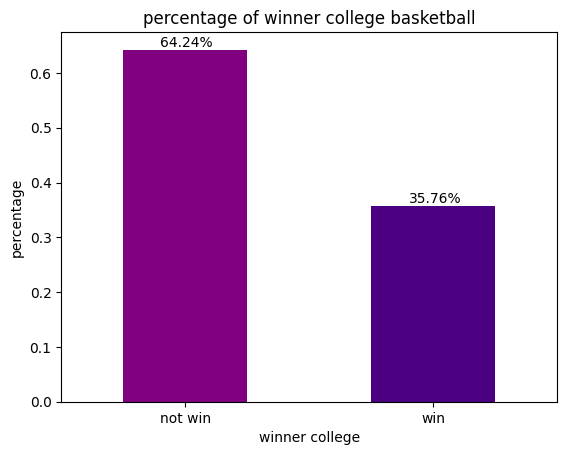

In [ ]:
Win = df_train['Win'].value_counts(normalize=True)
Win.plot(kind='bar', color=['purple','indigo'])
plt.title('percentage of winner college basketball')
plt.xlabel('winner college')
plt.ylabel('percentage')
plt.xticks([0,1],['not win','win'], rotation=0)
for i in range(len(Win)):
  plt.text(i-0.1, Win[i]+0.005, f"{Win[i]*100:.2f}%")
plt.show()

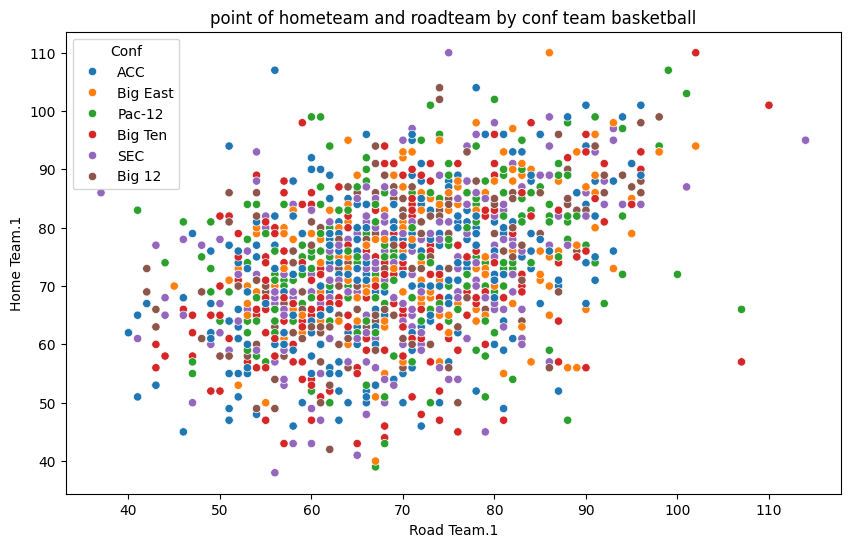

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Road Team.1', y='Home Team.1', hue='Conf', data=df_train).set(title='point of hometeam and roadteam by conf team basketball');

<ipython-input-7-02004aff0fbe>:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x='Road Team.1', y='Home Team.1', cbar=True, shade=True, cmap='Blues', data=df_train).set(title='Points home team and road team Basketball');


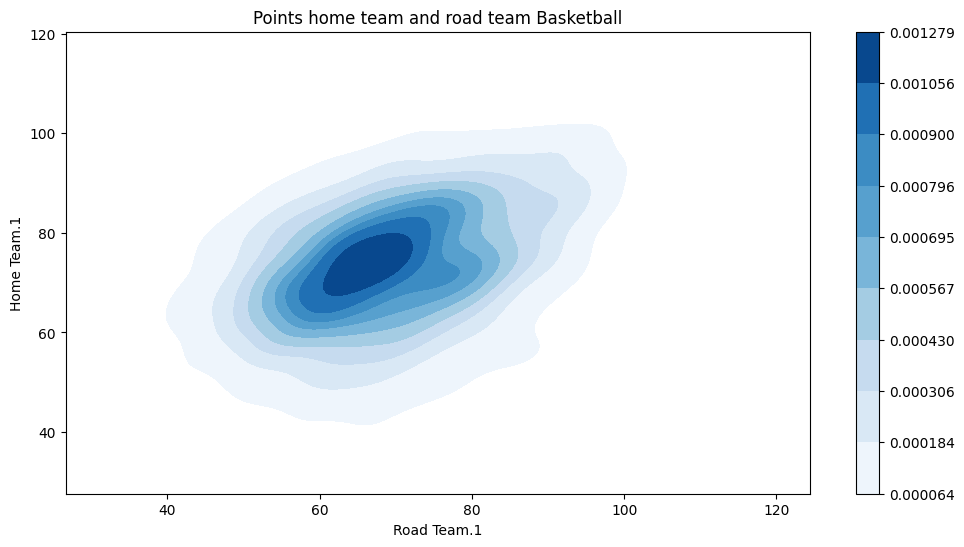

In [ ]:
plt.figure(figsize=(12,6))
sns.kdeplot(x='Road Team.1', y='Home Team.1', cbar=True, shade=True, cmap='Blues', data=df_train).set(title='Points home team and road team Basketball');

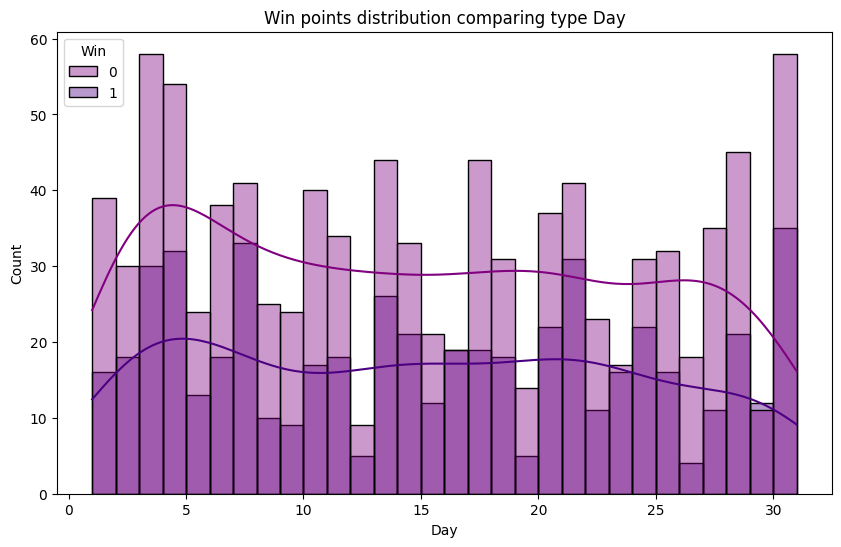

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_train, x='Day', hue='Win', kde=True, bins=30, palette=['purple','indigo'], alpha=0.4)
plt.title('Win points distribution comparing type Day')
plt.show()

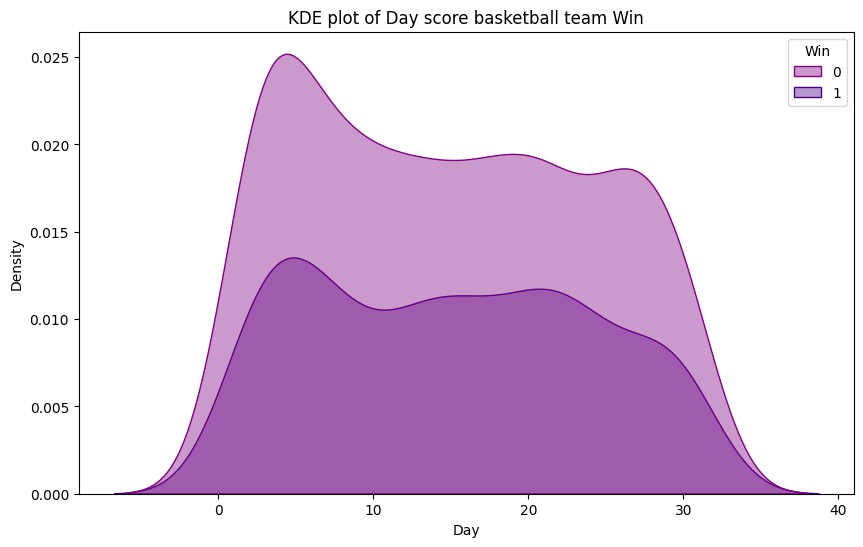

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_train, x='Day', hue='Win', fill=True, palette=['purple','indigo'], alpha=0.4)
plt.title('KDE plot of Day score basketball team Win')
plt.show()

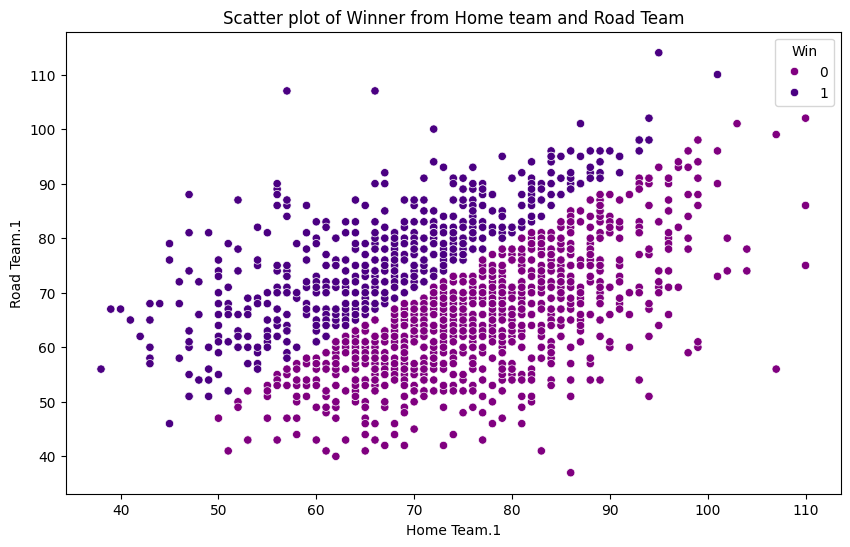

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='Home Team.1', y='Road Team.1', hue='Win', palette=['purple','indigo'])
plt.title('Scatter plot of Winner from Home team and Road Team')
plt.show()

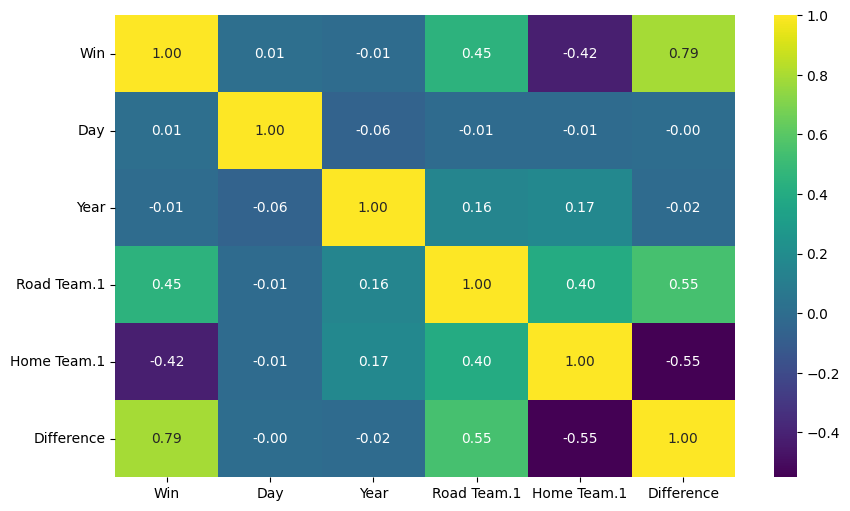

In [ ]:
corr_train = df_train.drop(columns=['OT','Conf','Locale','Month','Time','Weekday','Home Team','Road Team']).corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_train, annot=True, cmap='viridis', fmt='.2f')
plt.title('')
plt.show()

In [ ]:
unused_columns=['Difference','Conf','Locale','Year','Home Team','Road Team','Month','Weekday','Time','OT']
X_train = df_train.drop(columns=unused_columns)
y_train = df_train['Year'].values.reshape(-1,1)
X_val = df_val.drop(columns=unused_columns)
y_val = df_val['Year'].values.reshape(-1,1)

In [ ]:
HomeTeam_pipeline = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', MinMaxScaler())])
RoadTeam_pipeline = Pipeline([('scaler', StandardScaler())])
category_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder())
])
preprocessor = ColumnTransformer([
    ('Home Team.1', HomeTeam_pipeline,['Home Team.1']),
    ('Road Team.1', RoadTeam_pipeline,['Road Team.1']),
    ('category', category_pipeline,['Day'])
    ], remainder='passthrough'
)

In [ ]:
preprocessor.fit(X_train)
X_train_preprocessed = preprocessor.transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

In [ ]:
import pickle
with open('preprocessor.pkl','wb') as file:
  pickle.dump(preprocessor, file)

In [ ]:
log_reg = LogisticRegression()
svm = SVC()

In [ ]:
log_reg.fit(X_train_preprocessed, y_train.ravel())
svm.fit(X_train_preprocessed, y_train.ravel())
print("model fitted")

model fitted


In [ ]:
from time import perf_counter
log_reg_start = perf_counter()
log_reg.fit(X_train_preprocessed, y_train.ravel())
print(f"Logistic Regression fitted in {perf_counter()-log_reg_start:.4f}seconds")
svm_start = perf_counter()
svm.fit(X_train_preprocessed, y_train.ravel())
print(f"Support Vector Machine fitted in {perf_counter()-svm_start:.4f}seconds")
print("Model fitted")

Logistic Regression fitted in 0.0635seconds
Support Vector Machine fitted in 0.1315seconds
Model fitted


In [ ]:
log_reg_val_pred = log_reg.predict(X_val_preprocessed)
svm_val_pred = svm.predict(X_val_preprocessed)
print("prediction done")

prediction done


In [ ]:
log_reg_accuracy = accuracy_score(y_val,log_reg_val_pred)
print(f"Logistic Regression Accuracy {log_reg_accuracy:.4f}")
svm_accuracy = accuracy_score(y_val,svm_val_pred)
print(f"Support Vector Machine Accuracy {svm_accuracy:.4f}")

Logistic Regression Accuracy 0.4444
Support Vector Machine Accuracy 0.4577


In [ ]:
log_reg_report = classification_report(y_val,log_reg_val_pred)
print("Logistic Regression")
print(log_reg_report)
svm_report = classification_report(y_val,svm_val_pred)
print("Support Vector Machine")
print(svm_report)

Logistic Regression
              precision    recall  f1-score   support

        2014       0.00      0.00      0.00         2
        2015       0.44      0.44      0.44        97
        2016       0.49      0.47      0.48        94
        2017       0.49      0.55      0.52        99
        2018       0.33      0.31      0.32        86

    accuracy                           0.44       378
   macro avg       0.35      0.35      0.35       378
weighted avg       0.44      0.44      0.44       378

Support Vector Machine
              precision    recall  f1-score   support

        2014       0.00      0.00      0.00         2
        2015       0.45      0.40      0.43        97
        2016       0.49      0.48      0.48        94
        2017       0.50      0.58      0.54        99
        2018       0.37      0.37      0.37        86

    accuracy                           0.46       378
   macro avg       0.36      0.37      0.36       378
weighted avg       0.45      0.46 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif